# PyIBS Example 1: Basic usage and calibration

This notebook introduces inverse binomial sampling (IBS): estimate a model's log-likelihood by simulating its responses, and attach an estimate of the uncertainty to each result. We use a model with a closed-form likelihood so that we can check the estimates against a known value, then explore how the number of repeats changes their noise and cost.

This is the first of three examples. The [second](./pyibs_example_2_maximum_likelihood_with_pybads.ipynb) fits the same model with PyBADS; the [third](./pyibs_example_3_posterior_with_pyvbmc.ipynb) uses PyVBMC for Bayesian inference. The notebook's code is also available as a [Python script](https://github.com/acerbilab/pyibs/blob/main/examples/scripts/pyibs_example_1_basic_usage.py).

See the [installation guide](https://acerbilab.github.io/pyibs/installation.html) for PyIBS and the packages needed to run this notebook.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from pyibs import IBS, ibs_basic
from pyibs.examples.psycho_model import psycho_generator, psycho_neg_logl

## 0. From simulations to a log-likelihood

For many models, generating a response is easy while computing its probability is difficult. IBS is for data with discrete responses: it estimates the log-probability of each observed response from independent simulations under that trial's conditions. It draws responses until the first match. If the match arrives at sample $K$, the estimate for that trial is

$$
\hat{\mathcal{L}}_i = -\sum_{k=1}^{K-1} \frac{1}{k}.
$$

A first-sample match gives 0. For any positive matching probability $p_i$, the expected estimate is exactly $\log p_i$: this is the unbiasedness property of IBS. Adding the independent trials' estimates gives the data's log-likelihood estimate. IBS also estimates its variance, and averaging several independent *repeats* reduces that variance.

The expected cost of a trial is $1/p_i$ simulated responses per repeat. Rare responses therefore take more work. A response with probability zero never matches.

PyIBS implements this procedure in Python. It can return an estimate together with its estimated standard deviation (SD), which lets PyBADS optimize a noisy likelihood and PyVBMC infer a posterior from one. These packages are among the lab's [tools for fitting models to data](https://acerbilab.org/model-fitting/).

## 1. A model with a known likelihood

The orientation discrimination model from the IBS paper describes an observer judging a stimulus of orientation $s$, in degrees. The response is rightwards ($r=1$) or leftwards ($r=-1$). The observer measures $s$ with Gaussian noise of SD $\sigma$ and responds rightwards when the measurement reaches the bias $\mu$. On a fraction $\gamma$ of trials, called lapses, the observer responds at random. We write the parameters as $\theta=(\eta,\mu,\gamma)$, where $\eta=\log\sigma$.

PyIBS includes the model in `pyibs.examples.psycho_model`. `psycho_generator(theta, S, rng)` draws one response for each orientation in `S`, using the NumPy generator `rng`. The companion function `psycho_neg_logl(theta, S, R)` evaluates the negative log-likelihood of responses `R` from the closed form

$$
\Pr(r=1\mid s,\theta)=\frac{\gamma}{2}+(1-\gamma)\,\Phi\!\left(\frac{s-\mu}{\sigma}\right),
$$

where $\Phi$ is the standard normal cumulative distribution function. A closed-form likelihood is the best choice for fitting this model. Here it supplies a reference for learning and checking IBS.

We generate 600 trials with orientations drawn from a normal distribution of SD 3°, and responses at $\theta_\text{true}=(\log 1,0.2,0.03)$. This is the data-generation recipe of MATLAB IBS's `ibs_example.m`. All three notebooks use the same data seed. Separate seeds spawned from one root seed supply independent streams for the data and the estimates, and make repeated runs reproducible.

In [2]:
# Independent seeds for the data and for the IBS estimates
seed_data, seed_ibs, seed_basic = np.random.SeedSequence(2026).spawn(3)

theta_true = np.array([math.log(1.0), 0.2, 0.03])  # log(sigma), bias, lapse
n_trials = 600

rng = np.random.default_rng(seed_data)
S = 3 * rng.standard_normal((n_trials, 1))  # Orientation of each trial
R = psycho_generator(theta_true, S, rng)  # Response of each trial

print("First orientations:", S[:5, 0].round(2))
print("First responses:   ", R[:5, 0])
print(f"Rightwards responses: {np.mean(R == 1):.1%}")

First orientations: [ 0.33  0.33  0.6  -0.58 -0.62]
First responses:    [ 1. -1.  1.  1. -1.]
Rightwards responses: 45.2%


## 2. Calling IBS

An `IBS` object stores the simulator, the observed responses and each trial's conditions. `response_matrix` and `design_matrix` each have one row per trial; here the design rows contain the orientations. When called with a parameter vector, the object asks the simulator for responses at that vector and returns an estimate.

The simulator receives the design rows of the trials being sampled. A trial can appear several times in one call, and every requested row must produce an independent response. Since `psycho_generator` has a parameter named `rng`, IBS passes it the object's generator, seeded by `random_seed`. Giving the object a seed separate from the data's seed keeps these simulations independent of the draws that generated the data.

We set `vectorized=True` to request several samples per trial in each simulator call. This suits a model that can simulate many responses cheaply at once. It also fixes the sampling schedule: the default `vectorized=None` times one sample of every trial at the object's first call with more than one repeat, and keeps its scheduling decision for later calls. A seed alone does not fix that timing decision.

In [3]:
ibs = IBS(psycho_generator, R, S, vectorized=True, random_seed=seed_ibs)

neg_logl = ibs(theta_true)
print(f"Negative log-likelihood estimate: {neg_logl:.2f}")

Negative log-likelihood estimate: 148.93


A call returns the *negative* log-likelihood by default, averaged over `num_reps=10` independent repeats. This is the sign an optimizer minimizes; `return_positive=True` returns the log-likelihood.

With `additional_output="std"`, the result is a tuple `(value, sd)`, ready for a method that accepts noisy evaluations. `additional_output="var"` supplies the variance estimate instead. Every call uses fresh samples, so repeated calls at the same parameters give independent estimates.

In [4]:
neg_logl, neg_logl_sd = ibs(theta_true, additional_output="std")
print(
    f"Negative log-likelihood estimate: {neg_logl:.2f} +/- {neg_logl_sd:.2f}"
)

Negative log-likelihood estimate: 151.12 +/- 3.33


`additional_output="full"` returns an `EstimateResult`, a dictionary whose keys can also be read as attributes:

- `neg_logl`, `neg_logl_var` and `neg_logl_std` give the estimate, its variance estimate and the square root of that variance estimate.
- `exit_flag` and `message` describe how sampling finished. Flag 0 means all repeats completed without clipping, flag 1 means the likelihood threshold `neg_logl_threshold` ended a repeat, and flag 2 means the time limit `max_time` stopped sampling. Both use their default, disabled settings here. The [FAQ explains the exit flags and the effects of stopping or selecting calls](https://acerbilab.github.io/pyibs/faq.html#faq-what-does-a-call-of-ibs-return).
- `elapsed_time` measures the call's duration in seconds.
- `num_samples_per_trial` and `fun_count` count simulated responses per trial and simulator calls, including surplus responses after a trial's last match.
- `neg_logl_trials` and `neg_logl_var_trials` give the per-trial estimates and variance estimates. With the unit trial weights used here, they sum to the totals.

In [5]:
result = ibs(theta_true, additional_output="full")
print(result)

              neg_logl: 152.69756373253406
          neg_logl_var: 11.080884558590599
          neg_logl_std: 3.3287962627037717
             exit_flag: 0
               message: 'All requested IBS repeats completed without reaching the likelihood threshold.'
          elapsed_time: 0.0024881999706849456
 num_samples_per_trial: 26.493333333333332
             fun_count: 10
       neg_logl_trials: array([0.55      , 0.48333333, 0.35      , ..., 0.        , 0.        ,
       0.        ], shape=(600,))
   neg_logl_var_trials: array([0.0475    , 0.04361111, 0.0325    , ..., 0.        , 0.        ,
       0.        ], shape=(600,))


For readers moving from MATLAB IBS, `num_reps` corresponds to `Nreps`, `additional_output="std"` to `ReturnStd`, and `return_positive` to `ReturnPositive`.

## 3. Comparing one estimate with the known value

The closed-form likelihood gives the exact negative log-likelihood at the same parameter vector. Expressing the difference in units of the reported SD makes its size easier to assess.

In [6]:
exact = psycho_neg_logl(theta_true, S, R)
print(f"IBS estimate: {neg_logl:.2f} +/- {neg_logl_sd:.2f}")
print(f"Exact value:  {exact:.2f}")
print(f"Difference:   {(neg_logl - exact) / neg_logl_sd:.2f} SDs")

IBS estimate: 151.12 +/- 3.33
Exact value:  152.47
Difference:   -0.41 SDs


## 4. Checking the mean and uncertainty

Unbiasedness concerns the mean over repeated estimates. Variance calibration concerns the mean of the reported *variance* estimates: it should match the variance of the estimates themselves. Neither property alone makes individual estimates Gaussian.

We draw 2,000 estimates at $\theta_\text{true}$, with 10 repeats each, and examine three quantities:

- the mean estimate, compared with the exact value and the standard error of that mean;
- the empirical SD of the estimates, compared with the root mean square of their reported SDs, which is the square root of the mean reported variance;
- the distribution of $z=(\text{estimate}-\text{exact})/\text{sd}$, compared with a standard normal curve.

Here each estimate combines many independent trial contributions and repeats, so a Gaussian approximation is plausible. The histogram checks how well it works for this model, data set and parameter vector.

In [7]:
n_estimates = 2000
estimates = np.array(
    [ibs(theta_true, additional_output="std") for _ in range(n_estimates)]
)
values, sds = estimates[:, 0], estimates[:, 1]
z = (values - exact) / sds

standard_error = values.std(ddof=1) / math.sqrt(n_estimates)
reported_sd = math.sqrt(np.mean(sds**2))  # Root mean square of the SDs
print(f"Exact value:            {exact:.2f}")
print(f"Mean of the estimates:  {values.mean():.2f} +/- {standard_error:.2f}")
print(f"SD of the estimates:    {values.std(ddof=1):.2f}")
print(f"RMS reported SD:        {reported_sd:.2f}")
print(f"z-scores: mean {z.mean():.3f}, SD {z.std(ddof=1):.3f}")

Exact value:            152.47
Mean of the estimates:  152.54 +/- 0.07
SD of the estimates:    3.28
RMS reported SD:        3.33
z-scores: mean 0.013, SD 0.983


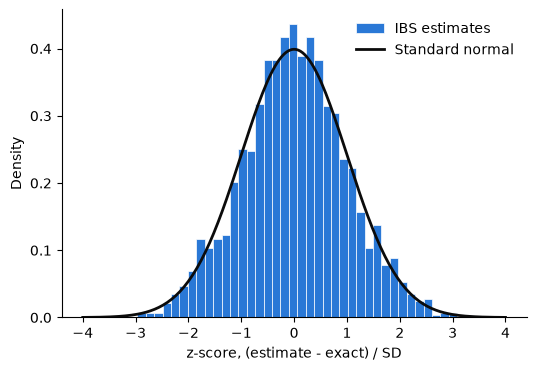

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    z,
    bins=40,
    density=True,
    color="#2a78d6",
    edgecolor="white",
    linewidth=0.5,
    label="IBS estimates",
)
x = np.linspace(-4, 4, 201)
ax.plot(x, norm.pdf(x), color="#0b0b0b", linewidth=2, label="Standard normal")
ax.set_xlabel("z-score, (estimate - exact) / SD")
ax.set_ylabel("Density")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

In this run, the mean estimate is close to the exact value, and the empirical SD is close to the root mean square reported SD. The z-score histogram is also close to a standard normal curve. These observations support the uncertainty estimates and a Gaussian noise approximation for this example. With fewer trials, fewer repeats or many first-sample matches, the distribution can be less Gaussian; the reported SD is itself an estimate.

## 5. Trading cost for precision

`num_reps` controls how many independent estimates are averaged. The variance of the average is inversely proportional to `num_reps`, and its SD is inversely proportional to its square root. The expected number of samples needed for the matches grows in proportion to the repeats; accelerated sampling adds some surplus.

In [9]:
print("num_reps     SD   SD * sqrt(num_reps)   samples per trial   calls")
for num_reps in [3, 10, 30, 100, 300, 1000]:
    result = ibs(theta_true, num_reps=num_reps, additional_output="full")
    print(
        f"{num_reps:8d} {result.neg_logl_std:6.2f} "
        f"{result.neg_logl_std * math.sqrt(num_reps):20.2f} "
        f"{result.num_samples_per_trial:19.1f} {result.fun_count:7d}"
    )

num_reps     SD   SD * sqrt(num_reps)   samples per trial   calls
       3   6.13                10.62                 7.8      11
      10   3.31                10.45                25.1      10
      30   1.92                10.51                86.9      10
     100   1.05                10.53               290.3       9
     300   0.61                10.52               792.2      10
    1000   0.33                10.54              2116.9      24


The reported `SD * sqrt(num_reps)` stays near the SD of a single repeat. The sample count grows roughly with `num_reps`, while batching keeps the number of simulator calls small. `num_samples_per_trial` counts all responses, including those generated after a trial has enough matches.

For fitting, choose the precision where the fit matters. PyBADS works best with an SD of about 1 or less near the solution; PyVBMC works best around 1, and not much above 3, where the posterior has most of its mass. Larger noise far from the solution is usually manageable. The FAQs of [PyBADS](https://acerbilab.github.io/pybads/faq.html#faq-can-pybads-handle-any-arbitrary-amount-of-noise-in-the-objective) and [PyVBMC](https://acerbilab.org/pyvbmc/faq.html#faq-how-large-can-the-noise-be-to-perform-successful-inferences-with-vbmc) explain these recommendations. For this data set, 100 repeats give an SD near 1; both later notebooks use that setting. Expensive simulations may require fewer repeats and a noisier target.

## 6. Reading the basic algorithm

`ibs_basic` exposes IBS as a short loop in `pyibs/ibs_basic.py`. It visits one trial at a time, simulates until a response matches, then adds the trial's estimate. The function is intended for teaching and follows the structure of MATLAB's `ibs_basic.m`; use `IBS` for fitting.

It returns one repeat's log-likelihood estimate and calls the simulator with one design row at a time, here a single orientation. It supplies no variance estimate.

In [10]:
loglik_basic = ibs_basic(
    psycho_generator, theta_true, R, S, random_seed=seed_basic
)
print(f"ibs_basic estimate (one repeat): {loglik_basic:.2f}")
print(f"Exact log-likelihood:            {-exact:.2f}")

ibs_basic estimate (one repeat): -145.27
Exact log-likelihood:            -152.47


A single repeat has roughly the SD shown in the `SD * sqrt(num_reps)` column above, so this estimate is appreciably noisier than the averages.

## 7. Using these estimates in a fit

The simulator supplies the IBS estimate, the reported variance describes its uncertainty, and the number of repeats controls the cost of reducing that uncertainty. A model with a known likelihood lets us check each part before using the same interface with a harder model.

The [next notebook](./pyibs_example_2_maximum_likelihood_with_pybads.ipynb) fits this data set by maximum-likelihood estimation with PyBADS. The [third](./pyibs_example_3_posterior_with_pyvbmc.ipynb) uses PyVBMC to infer a posterior and model evidence.

## Reference

van Opheusden, B., Acerbi, L. & Ma, W. J. (2020). Unbiased and efficient log-likelihood estimation with inverse binomial sampling. *PLOS Computational Biology* 16(12): e1008483. [https://doi.org/10.1371/journal.pcbi.1008483](https://doi.org/10.1371/journal.pcbi.1008483)